In [1]:
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Tóm tắt dữ liệu
Quy mô dữ liệu:
- Hơn 5000 hàng dữ liệu
- 14 cột mô tả tình trạng, trạng thái, sức khỏe của mỗi người


## Các thuộc tính đầu vào
- age: Tuổi
- gender: Giới tính
- pulse_rate: Nhịp tim (Lần/phút)
- systolic_bp: Huyết áp tâm thu
- diastolic_bp: Huyết áp tâm trương
- glucose: Mức đường huyết
- height: Chiều cao
- height: Cân nặng
- bmi: Chỉ số khối cơ thể
- family_diabetes: Tiền sử bị bệnh tiểu đường trong gia đình
- hypertensive: Cá nhân mắc bệnh tăng huyết áp
- family_hypertension: Tiền sử tăng huyết áp trong gia đình
- cardiovascular_disease: Cá nhân mắc bệnh tim mạch
- stroke: Cá nhân mắc bệnh độ quỵ

## Thuộc tính đầu ra
- diabetic: Có bị tiểu đường không

In [2]:
df = pd.read_csv(r'C:/Users/Duong/Documents/DataEngineer/tieuDuong/tieuduong/Train.csv')
df.head()

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No


In [3]:
df.tail()

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
5283,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5284,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5285,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5286,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No
5287,26,Female,80,134,93,5.15,1.47,67.1,30.92,0,0,0,0,0,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5288 non-null   int64  
 1   gender                  5288 non-null   object 
 2   pulse_rate              5288 non-null   int64  
 3   systolic_bp             5288 non-null   int64  
 4   diastolic_bp            5288 non-null   int64  
 5   glucose                 5288 non-null   float64
 6   height                  5288 non-null   float64
 7   weight                  5288 non-null   float64
 8   bmi                     5288 non-null   float64
 9   family_diabetes         5288 non-null   int64  
 10  hypertensive            5288 non-null   int64  
 11  family_hypertension     5288 non-null   int64  
 12  cardiovascular_disease  5288 non-null   int64  
 13  stroke                  5288 non-null   int64  
 14  diabetic                5288 non-null   

## PreProcessing

Xử lý bất thường

In [5]:
#Bỏ đi ông nào cao < 1m
df = df.drop(df[df['height'] < 1.0].index).reset_index(drop=True)
df = df.dropna().reset_index(drop=True)
df['diabetic'] = df['diabetic'].map({'No': 0, 'Yes': 1})
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

selected_cols = ['age', 'glucose', 'bmi', 'systolic_bp', 'diastolic_bp', 
                 'family_diabetes', 'hypertensive', 'stroke', 'diabetic']

In [6]:
df = df.copy()
# chỉ số khối trong cơ thể không nhỏ hơn 60
df = df[df['bmi'] <= 60]
# đường trong cơ thể không thể nhỏ hơn 25 mmol/l 
df = df[df['glucose'] <= 25]
# huyết áp
df = df[df['systolic_bp'] >= 70]   # <70 là sốc
df = df[df['systolic_bp'] <= 250] # <= 250 thì đi viện

xử lý giá trị trùng lặp

In [7]:
num_duplicates = df.duplicated().sum()
print(f"Số lượng dòng trùng lặp: {num_duplicates}")

if num_duplicates > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

Số lượng dòng trùng lặp: 0


Xử lý giá trị thiếu

In [8]:
# Kiểm tra tổng số giá trị thiếu ở mỗi cột
missing_info = df.isnull().sum()
print("Số lượng giá trị thiếu ở mỗi cột:")
print(missing_info[missing_info > 0])

# Liệt kê các cột số cần điền giá trị
cols_to_fix = ['age', 'pulse_rate', 'systolic_bp', 'diastolic_bp', 'glucose', 'height', 'weight', 'bmi']

# Điền giá trị thiếu bằng trung vị của cột đó
for col in cols_to_fix:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())
print("Đã xử lý xong giá trị thiếu bằng phương pháp điền trung vị.")

Số lượng giá trị thiếu ở mỗi cột:
Series([], dtype: int64)
Đã xử lý xong giá trị thiếu bằng phương pháp điền trung vị.


In [9]:
def handle_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
        
    return df_clean

cols_to_check = ['age', 'pulse_rate', 'systolic_bp', 'diastolic_bp', 'glucose', 'height', 'weight', 'bmi']
df = handle_outliers_iqr(df, cols_to_check)
print("Outliers handled using IQR method (Capping).")

Outliers handled using IQR method (Capping).


In [10]:
print("\nKiểu dữ liệu:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())


Kiểu dữ liệu:
age                         int64
gender                      int64
pulse_rate                  int64
systolic_bp                 int64
diastolic_bp              float64
glucose                   float64
height                    float64
weight                    float64
bmi                       float64
family_diabetes             int64
hypertensive                int64
family_hypertension         int64
cardiovascular_disease      int64
stroke                      int64
diabetic                    int64
dtype: object

Missing values:
age                       0
gender                    0
pulse_rate                0
systolic_bp               0
diastolic_bp              0
glucose                   0
height                    0
weight                    0
bmi                       0
family_diabetes           0
hypertensive              0
family_hypertension       0
cardiovascular_disease    0
stroke                    0
diabetic                  0
dtype: int64


In [11]:
df.nunique().sort_values()

gender                       2
family_hypertension          2
stroke                       2
diabetic                     2
cardiovascular_disease       2
family_diabetes              2
hypertensive                 2
height                      27
age                         60
pulse_rate                  65
diastolic_bp                69
systolic_bp                109
weight                     458
glucose                    673
bmi                       1250
dtype: int64

In [12]:
df.isna().sum()

age                       0
gender                    0
pulse_rate                0
systolic_bp               0
diastolic_bp              0
glucose                   0
height                    0
weight                    0
bmi                       0
family_diabetes           0
hypertensive              0
family_hypertension       0
cardiovascular_disease    0
stroke                    0
diabetic                  0
dtype: int64

In [13]:
df['gender'].value_counts().head(5)

gender
0    3737
1    1532
Name: count, dtype: int64

In [14]:
df['diabetic'].value_counts().head(5)

diabetic
0    4932
1     337
Name: count, dtype: int64

In [15]:
glucose_mean = df['glucose'].mean()

high_glucose_df = df[df['glucose'] > glucose_mean]
num_high_glucose = len(high_glucose_df)

total_people = len(df)
percentage = (num_high_glucose / total_people) * 100

print(f"Mức Glucose trung bình: {glucose_mean:.2f} mmol/L")
print(f"Số lượng người có mức Glucose cao hơn trung bình: {num_high_glucose} người")
print(f"Tỷ lệ: {percentage:.2f}% trên tổng số dữ liệu")
print("\nThống kê tình trạng bệnh trong nhóm Glucose cao:")
print(high_glucose_df['diabetic'].value_counts())

Mức Glucose trung bình: 7.24 mmol/L
Số lượng người có mức Glucose cao hơn trung bình: 2189 người
Tỷ lệ: 41.54% trên tổng số dữ liệu

Thống kê tình trạng bệnh trong nhóm Glucose cao:
diabetic
0    1960
1     229
Name: count, dtype: int64


In [16]:
bmi_mean = df['bmi'].mean()
# Lọc ra những người có chỉ số BMI cao hơn mức trung bình
high_bmi_df = df[df['bmi'] > bmi_mean]

num_high_bmi = len(high_bmi_df)
total_people = len(df)
percentage = (num_high_bmi / total_people) * 100

print(f"Trung bình BMI: {bmi_mean:.2f}")
print(f"Số người có mức BMI > trung bình: {num_high_bmi}")
print(f"Phần trăm: {percentage:.2f}% của tổng dữ liệu")
print("\nDiabetic số người :")
print(high_bmi_df['diabetic'].value_counts())

Trung bình BMI: 22.25
Số người có mức BMI > trung bình: 2440
Phần trăm: 46.31% của tổng dữ liệu

Diabetic số người :
diabetic
0    2230
1     210
Name: count, dtype: int64


# EDA

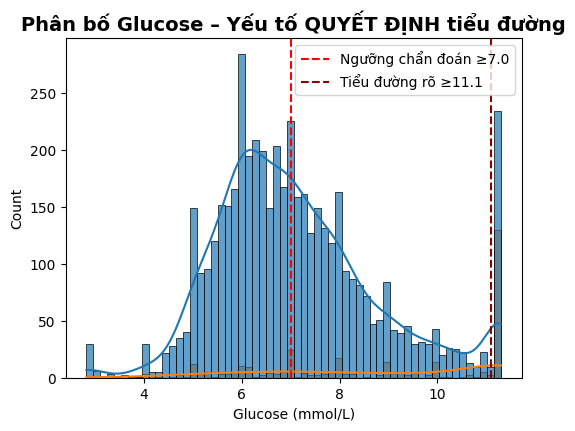

In [17]:
fig = plt.figure(figsize=(20, 15))

plt.subplot(3, 3, 1)
sns.histplot(data=df, x='glucose', hue='diabetic', bins=60, kde=True, alpha=0.7)
plt.title('Phân bố Glucose – Yếu tố QUYẾT ĐỊNH tiểu đường', fontsize=14, fontweight='bold')
plt.xlabel('Glucose (mmol/L)')
plt.axvline(7.0, color='red', linestyle='--', label='Ngưỡng chẩn đoán ≥7.0')
plt.axvline(11.1, color='darkred', linestyle='--', label='Tiểu đường rõ ≥11.1')
plt.legend()

<Figure size 2000x1500 with 0 Axes>

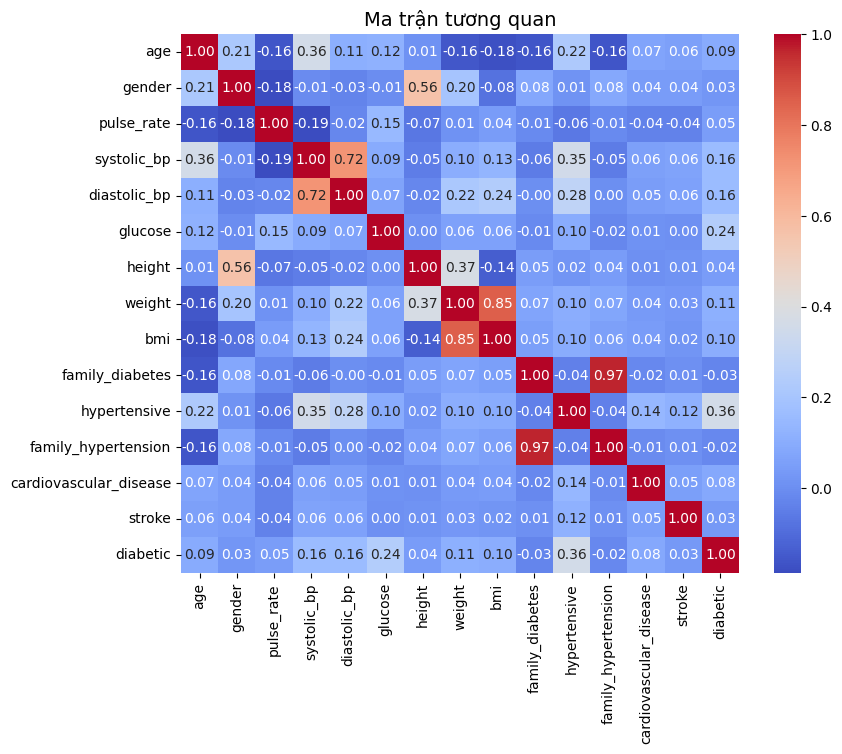

In [18]:
fig = plt.figure(figsize=(20, 15))
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan', fontsize=14)
plt.show()

C:\Users\Duong\AppData\Local\Temp\ipykernel_21200\2242379066.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=ty_le.index, y=ty_le.values, palette="Reds")


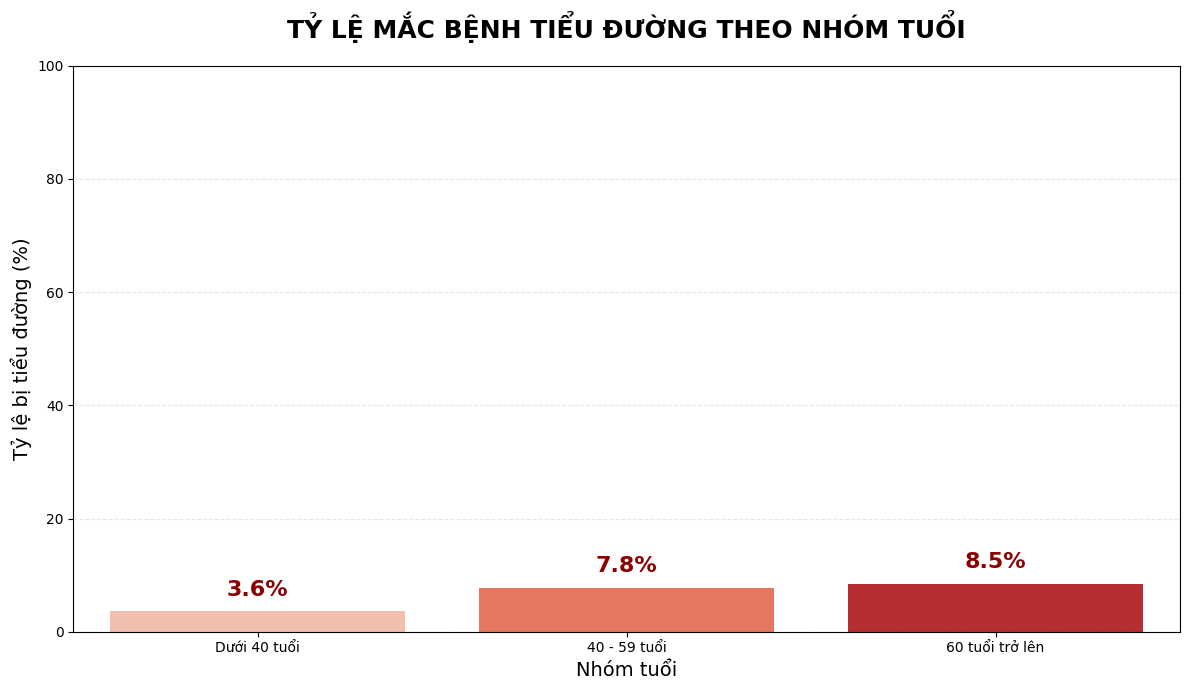

In [19]:
def nhom_tuoi(age):
    if age < 40:
        return "Dưới 40 tuổi"
    elif age < 60:
        return "40 - 59 tuổi"
    else:
        return "60 tuổi trở lên"
df['nhom_tuoi'] = df['age'].apply(nhom_tuoi)

ty_le = df.groupby('nhom_tuoi')['diabetic'].mean() * 100
order = ["Dưới 40 tuổi", "40 - 59 tuổi", "60 tuổi trở lên"]
ty_le = ty_le.reindex(order)

plt.figure(figsize=(12, 7))
bars = sns.barplot(x=ty_le.index, y=ty_le.values, palette="Reds")
plt.title('TỶ LỆ MẮC BỆNH TIỂU ĐƯỜNG THEO NHÓM TUỔI', 
          fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Tỷ lệ bị tiểu đường (%)', fontsize=14)
plt.xlabel('Nhóm tuổi', fontsize=14)
plt.ylim(0, 100)

for i, v in enumerate(ty_le.values):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', va='bottom', 
             fontsize=16, fontweight='bold', color='darkred')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

C:\Users\Duong\AppData\Local\Temp\ipykernel_21200\2946938600.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Nữ', 'Nam'], y=rate.values, palette=['pink', 'skyblue'])


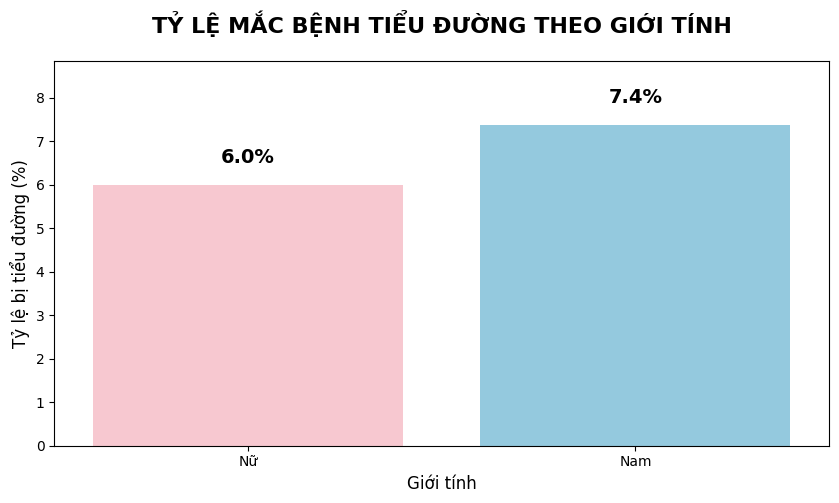

In [20]:
rate = df.groupby('gender')['diabetic'].mean() * 100
plt.figure(figsize=(10,5))
sns.barplot(x=['Nữ', 'Nam'], y=rate.values, palette=['pink', 'skyblue'])
plt.title('TỶ LỆ MẮC BỆNH TIỂU ĐƯỜNG THEO GIỚI TÍNH', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Tỷ lệ bị tiểu đường (%)', fontsize=12)
plt.xlabel('Giới tính', fontsize=12)

for i, v in enumerate(rate.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=14)
plt.ylim(0, max(rate)*1.2)
plt.show()

C:\Users\Duong\AppData\Local\Temp\ipykernel_21200\2634412147.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=['Có người nhà bị', 'Không có người nhà bị'],


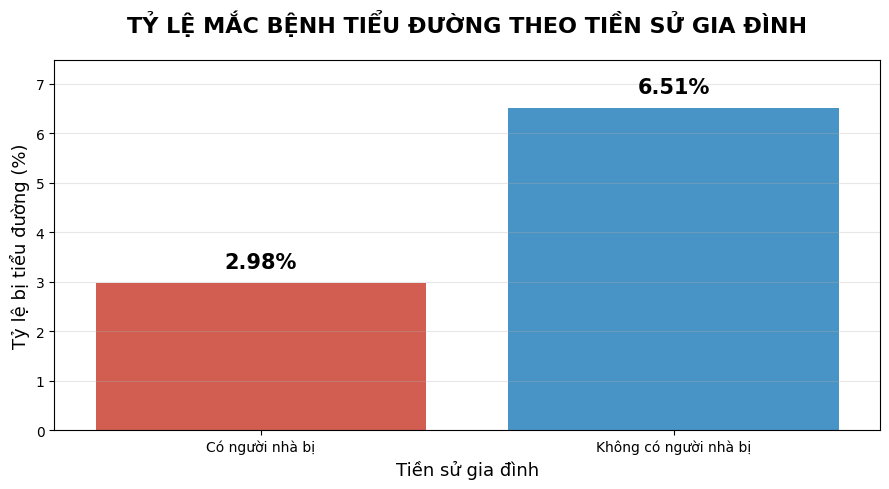

In [21]:
rate = df.groupby('family_diabetes')['diabetic'].mean() * 100
# Sắp xếp đúng thứ tự: 1 (Có) trước, 0 (Không) sau
rate = rate.reindex([1, 0])
plt.figure(figsize=(9, 5))
bars = sns.barplot(x=['Có người nhà bị', 'Không có người nhà bị'], 
                   y=rate.values, 
                   palette=['#e74c3c', '#3498db'])
plt.title('TỶ LỆ MẮC BỆNH TIỂU ĐƯỜNG THEO TIỀN SỬ GIA ĐÌNH', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Tỷ lệ bị tiểu đường (%)', fontsize=13)
plt.xlabel('Tiền sử gia đình', fontsize=13)

for i, v in enumerate(rate.values):
    plt.text(i, v + 0.3, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=15)

plt.ylim(0, max(rate.values)*1.15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\Duong\AppData\Local\Temp\ipykernel_21200\2229457658.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


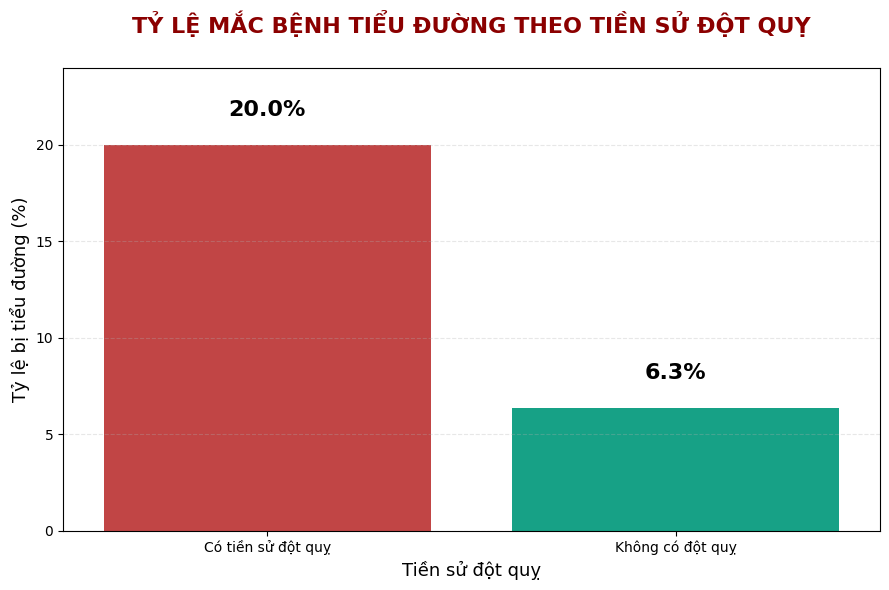

In [22]:
rate = df.groupby('stroke')['diabetic'].mean() * 100
rate = rate.reindex([1, 0])

plt.figure(figsize=(9, 6))
bars = sns.barplot(
    x=['Có tiền sử đột quỵ', 'Không có đột quỵ'],
    y=rate.values,
    palette=['#d63031', '#00b894']   # Đỏ = nguy hiểm, Xanh = an toàn
)
plt.title('TỶ LỆ MẮC BỆNH TIỂU ĐƯỜNG THEO TIỀN SỬ ĐỘT QUỴ', 
          fontsize=16, fontweight='bold', pad=25, color='darkred')
plt.ylabel('Tỷ lệ bị tiểu đường (%)', fontsize=13)
plt.xlabel('Tiền sử đột quỵ', fontsize=13)

for i, v in enumerate(rate.values):
    plt.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=16)
plt.ylim(0, max(rate.values)*1.2)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

C:\Users\Duong\AppData\Local\Temp\ipykernel_21200\953282125.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


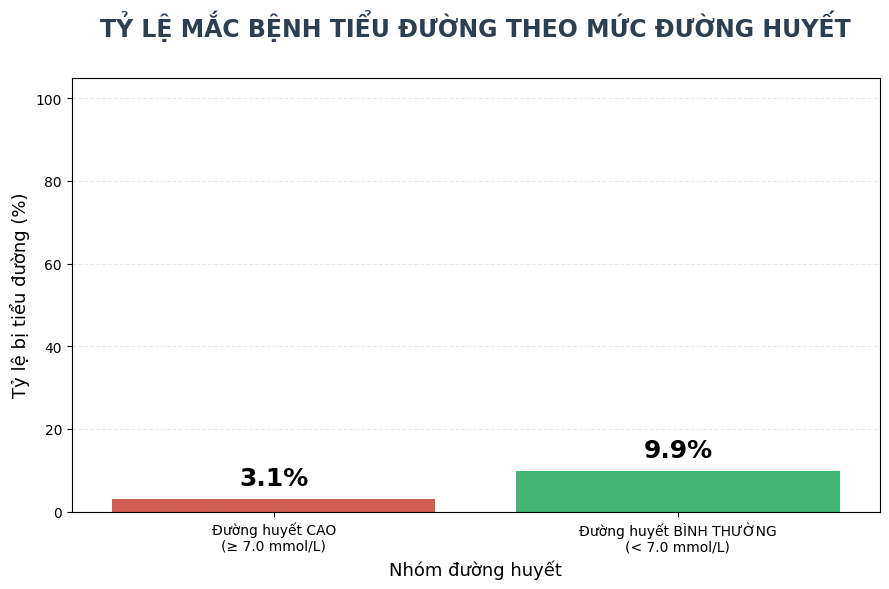

In [23]:
df['glucose_group'] = df['glucose'].apply(lambda x: 'Cao (≥7.0)' if x >= 7.0 else 'Bình thường (<7.0)')

rate = df.groupby('glucose_group')['diabetic'].mean() * 100
plt.figure(figsize=(9, 6))
bars = sns.barplot(
    x=['Đường huyết CAO\n(≥ 7.0 mmol/L)', 'Đường huyết BÌNH THƯỜNG\n(< 7.0 mmol/L)'],
    y=rate.values,
    palette=['#e74c3c', '#2ecc71']   # Đỏ = nguy hiểm, Xanh lá = an toàn
)
plt.title('TỶ LỆ MẮC BỆNH TIỂU ĐƯỜNG THEO MỨC ĐƯỜNG HUYẾT', 
          fontsize=17, fontweight='bold', pad=30, color='#2c3e50')
plt.ylabel('Tỷ lệ bị tiểu đường (%)', fontsize=13)
plt.xlabel('Nhóm đường huyết', fontsize=13)

for i, v in enumerate(rate.values):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', va='bottom', 
             fontweight='bold', fontsize=18, color='black')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

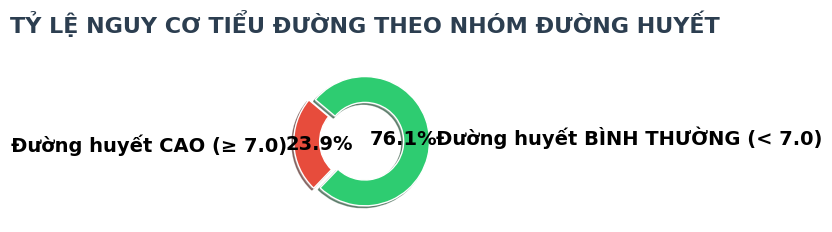

In [ ]:
labels = ['Đường huyết CAO (≥ 7.0)', 'Đường huyết BÌNH THƯỜNG (< 7.0)']
sizes = rate.values
colors = ['#e74c3c', '#2ecc71']
explode = (0.1, 0) 

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140,
        textprops={'fontsize': 14, 'fontweight': 'bold'},
        wedgeprops={'width': 0.4, 'edgecolor': 'w'})

plt.title('TỶ LỆ NGUY CƠ TIỂU ĐƯỜNG THEO NHÓM ĐƯỜNG HUYẾT', 
          fontsize=16, fontweight='bold', color='#2c3e50', pad=20)
plt.tight_layout()
plt.show()

C:\Users\Duong\AppData\Local\Temp\ipykernel_21200\2312604654.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=rate.index, y=rate.values,


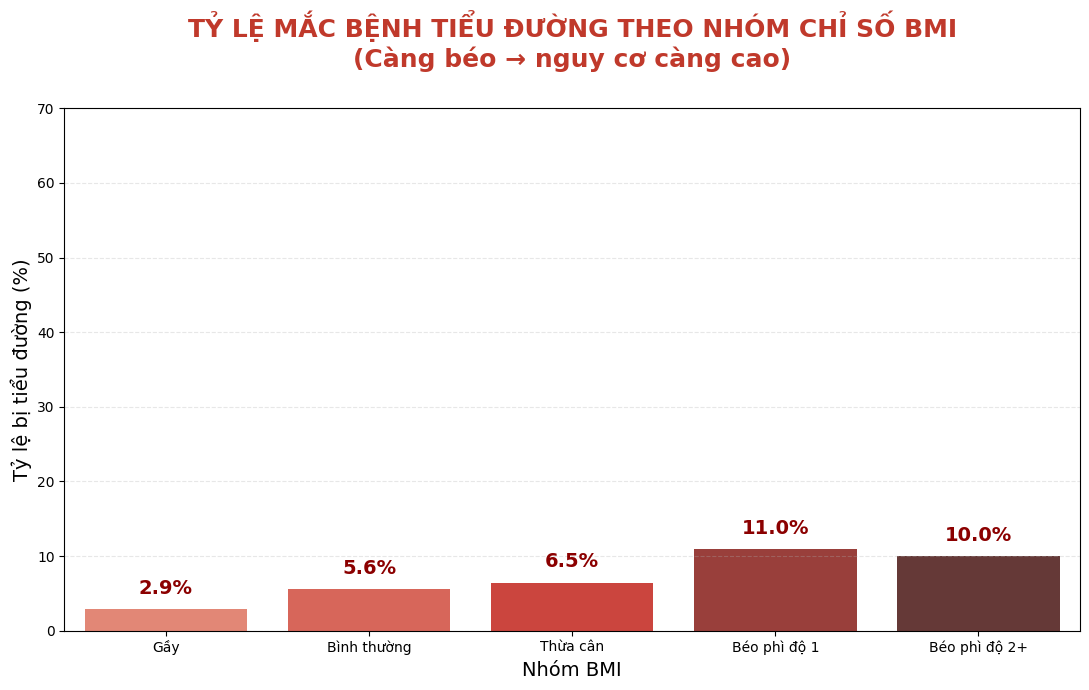

In [25]:
def phan_nhom_bmi(bmi):
    if bmi < 18.5:  return "Gầy"
    elif bmi < 23:   return "Bình thường"
    elif bmi < 25:   return "Thừa cân"
    elif bmi < 30:   return "Béo phì độ 1"
    else:            return "Béo phì độ 2+"

df['bmi_group'] = df['bmi'].apply(phan_nhom_bmi)
rate = df.groupby('bmi_group')['diabetic'].mean() * 100
order = ["Gầy", "Bình thường", "Thừa cân", "Béo phì độ 1", "Béo phì độ 2+"]
rate = rate.reindex(order)
plt.figure(figsize=(11, 7))
bars = sns.barplot(x=rate.index, y=rate.values, 
                   palette="Reds_d")
plt.title('TỶ LỆ MẮC BỆNH TIỂU ĐƯỜNG THEO NHÓM CHỈ SỐ BMI\n(Càng béo → nguy cơ càng cao)', 
          fontsize=18, fontweight='bold', pad=30, color='#c0392b')
plt.ylabel('Tỷ lệ bị tiểu đường (%)', fontsize=14)
plt.xlabel('Nhóm BMI', fontsize=14)
plt.ylim(0, 70)

for i, v in enumerate(rate.values):
    plt.text(i, v + 1.5, f'{v:.1f}%', ha='center', va='bottom', 
             fontsize=14, fontweight='bold', color='darkred')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

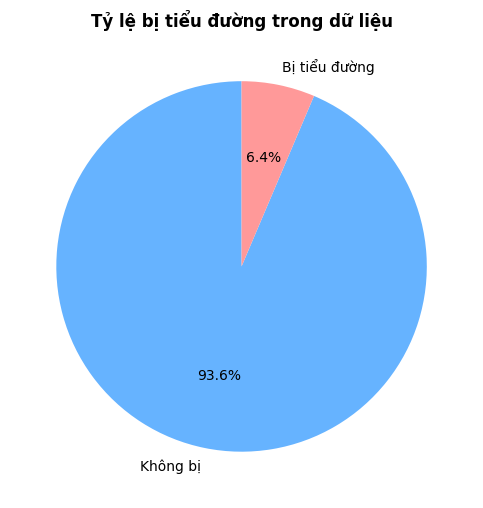

In [26]:
fig = plt.figure(figsize=(20, 15))
plt.subplot(3, 3, 9)
sizes = df['diabetic'].value_counts()
plt.pie(sizes, labels=['Không bị', 'Bị tiểu đường'], autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Tỷ lệ bị tiểu đường trong dữ liệu', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\Duong\AppData\Local\Temp\ipykernel_21200\3089594284.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10], palette="viridis")


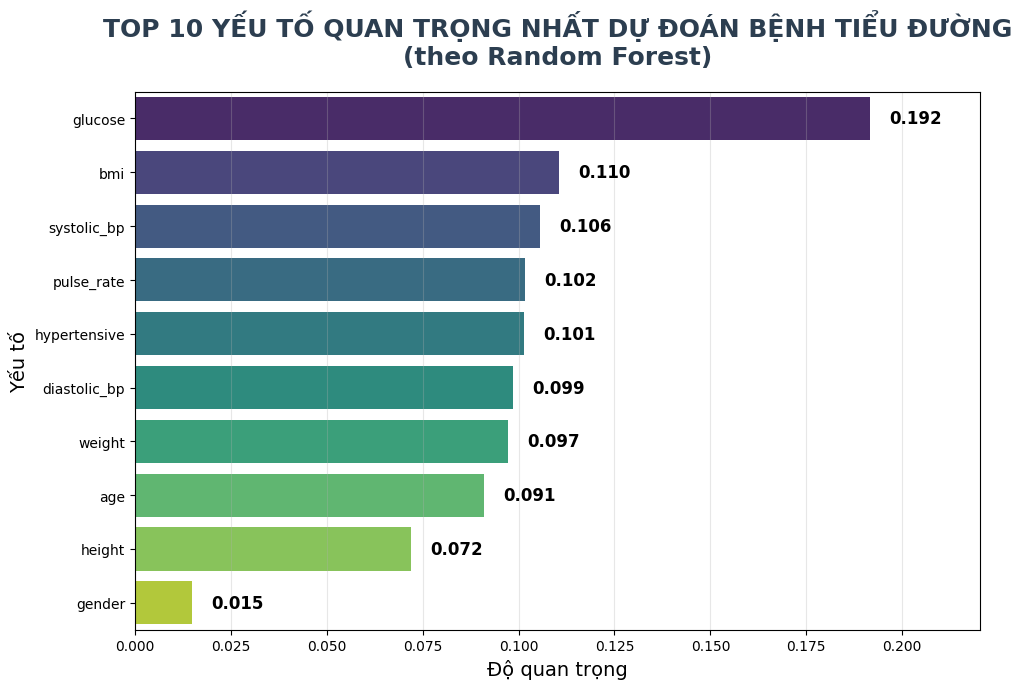

In [27]:
# Chỉ giữ lại cột số để train model
df_model = df.select_dtypes(include=['float64', 'int64'])
X = df_model.drop('diabetic', axis=1)
y = df_model['diabetic']
# Train Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X, y)
# Feature importance
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10], palette="viridis")
plt.title('TOP 10 YẾU TỐ QUAN TRỌNG NHẤT DỰ ĐOÁN BỆNH TIỂU ĐƯỜNG\n'
          '(theo Random Forest)', fontsize=18, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('Độ quan trọng', fontsize=14)
plt.ylabel('Yếu tố', fontsize=14)

for i, v in enumerate(feat_imp.values[:10]):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=12)

plt.xlim(0, max(feat_imp.values[:10]) * 1.15)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Chia dataset 1 cái để test và 1 cái để train 

In [28]:
df_model = df.select_dtypes(include=['number'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
print(f"\nTrain: {X_train.shape[0]} mẫu, Test: {X_test.shape[0]} mẫu")
print(f"Tỷ lệ dương tính trong train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")


Train: 4215 mẫu, Test: 1054 mẫu
Tỷ lệ dương tính trong train: 0.064, test: 0.064


In [30]:
print(y_train.value_counts())

diabetic
0    3945
1     270
Name: count, dtype: int64


Chuẩn hóa

In [31]:
scaler = StandardScaler()
cols_to_scale = ['age', 'pulse_rate', 'systolic_bp', 'diastolic_bp', 'glucose',
                 'height', 'weight', 'bmi']

X_train_scaled = X_train.copy() 
X_test_scaled  = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

Sử dụng Smote để sinh dữ liệu nhân tạo
sau đó sinh ra dữ liệu mới bởi vì số bệnh nhân mắc bệnh ít quá mô hình dễ bị dự đoán nhầm

In [32]:
smote = SMOTE(random_state=42)
# sinh dữ liệu
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Sau khi SMOTE:", y_train_smote.value_counts())

Sau khi SMOTE: diabetic
0    3945
1    3945
Name: count, dtype: int64


# Huấn Luyện Mô Hình

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)
def evaluate_clf(model, model_name, X_test, y_test):
    """
    Hàm đánh giá mô hình phân loại.
    Trả về: accuracy, precision, recall, f1 + vẽ 2 biểu đồ quan trọng.
    (Đã loại bỏ ROC AUC và ROC Curve theo yêu cầu)
    """

    y_pred = model.predict(X_test)

    # Lấy xác suất dự đoán (chỉ dùng cho Precision-Recall Curve)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    print(f"\n===== {model_name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Chỉ vẽ 2 biểu đồ
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axs[0])
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axs[1])

    axs[0].set_title("Precision-Recall Curve")
    axs[1].set_title("Confusion Matrix")

    plt.tight_layout()
    plt.show()
    
    # Lưu vào bảng kết quả (không có roc_auc)
    return {
        "modelname": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

# Cập nhật DataFrame để phù hợp
model_metrics = pd.DataFrame(columns=[
    "modelname", "accuracy", "precision", "recall", "f1"
])

# Logistic Regression


- Trước khi Smote dữ liệu


===== Logistic Regression (Trước SMOTE) =====
Accuracy : 0.8102
Precision: 0.2170
Recall   : 0.7612
F1-score : 0.3377

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89       987
           1       0.22      0.76      0.34        67

    accuracy                           0.81      1054
   macro avg       0.60      0.79      0.61      1054
weighted avg       0.93      0.81      0.85      1054



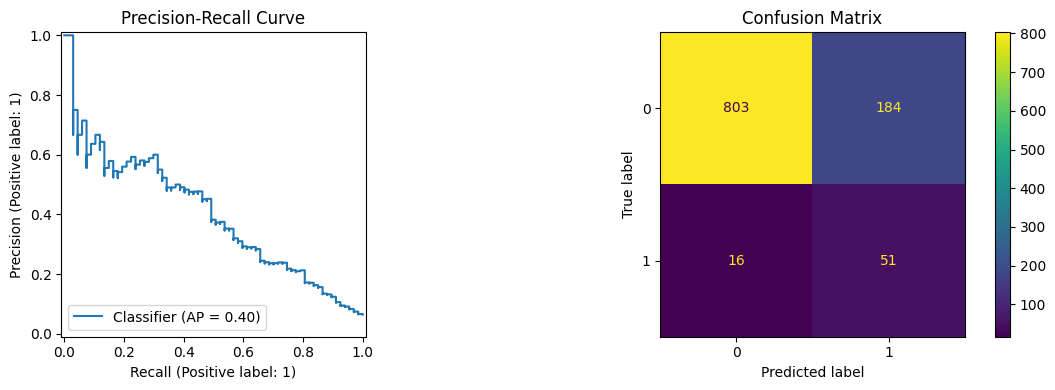

In [34]:
logreg_before = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg_before.fit(X_train_scaled, y_train)
result1 = evaluate_clf(logreg_before, "Logistic Regression (Trước SMOTE)", X_test_scaled, y_test)

- Sau khi Smote dữ liệu

Sau SMOTE:

===== Logistic Regression (Sau SMOTE) =====
Accuracy : 0.7884
Precision: 0.2023
Recall   : 0.7910
F1-score : 0.3222

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.87       987
           1       0.20      0.79      0.32        67

    accuracy                           0.79      1054
   macro avg       0.59      0.79      0.60      1054
weighted avg       0.93      0.79      0.84      1054



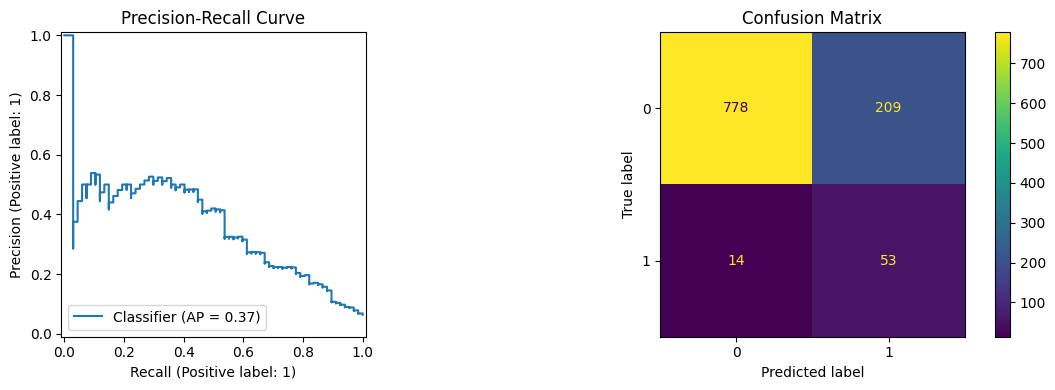

In [35]:
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Sau SMOTE:")
logreg_after = LogisticRegression(max_iter=1000, random_state=42) 
logreg_after.fit(X_train_smote, y_train_smote)
result2 = evaluate_clf(logreg_after, "Logistic Regression (Sau SMOTE)", X_test_scaled, y_test)

# Random Forest


===== Random Forest =====
Accuracy : 0.9137
Precision: 0.3462
Recall   : 0.4030
F1-score : 0.3724

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       987
           1       0.35      0.40      0.37        67

    accuracy                           0.91      1054
   macro avg       0.65      0.68      0.66      1054
weighted avg       0.92      0.91      0.92      1054



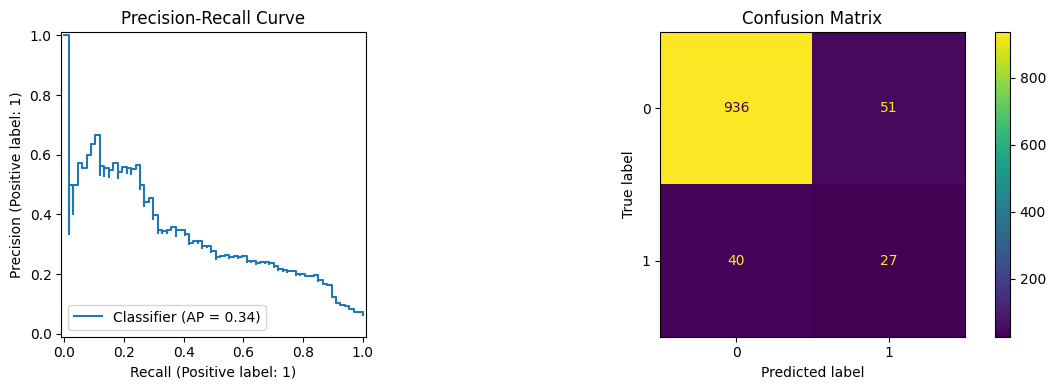

C:\Users\Duong\AppData\Local\Temp\ipykernel_21200\3948999561.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_metrics = pd.concat([model_metrics, pd.DataFrame([metrics])], ignore_index=True)


In [36]:
X_res, y_res = smote.fit_resample(X_train_scaled, y_train)
rf = RandomForestClassifier(n_estimators=800, random_state=42, n_jobs=-1)
rf.fit(X_res, y_res)
metrics = evaluate_clf(rf, 'Random Forest', X_test_scaled, y_test)
model_metrics = pd.concat([model_metrics, pd.DataFrame([metrics])], ignore_index=True)

# Đánh giá mô hình


===== Logistic =====
Accuracy : 0.7884
Precision: 0.2023
Recall   : 0.7910
F1-score : 0.3222

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.87       987
           1       0.20      0.79      0.32        67

    accuracy                           0.79      1054
   macro avg       0.59      0.79      0.60      1054
weighted avg       0.93      0.79      0.84      1054



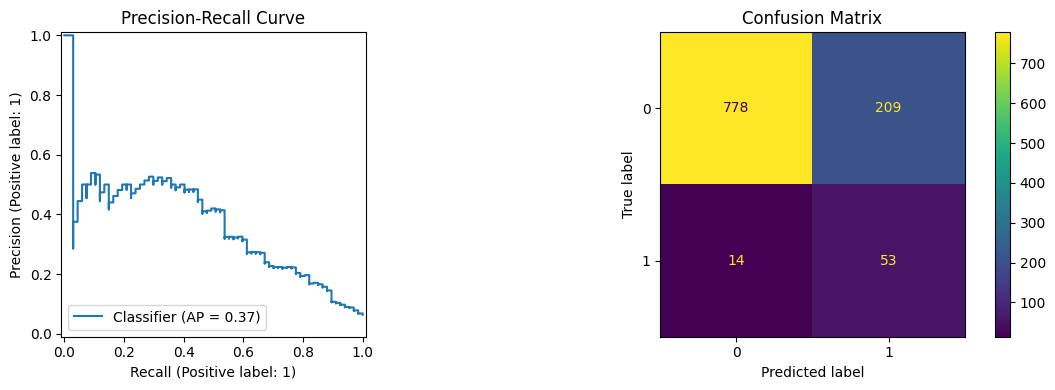

C:\Users\Duong\AppData\Local\Temp\ipykernel_21200\2915846855.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_metrics = pd.concat([model_metrics, pd.DataFrame([metrics_log])], ignore_index=True)



===== Random Forest =====
Accuracy : 0.9137
Precision: 0.3462
Recall   : 0.4030
F1-score : 0.3724

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       987
           1       0.35      0.40      0.37        67

    accuracy                           0.91      1054
   macro avg       0.65      0.68      0.66      1054
weighted avg       0.92      0.91      0.92      1054



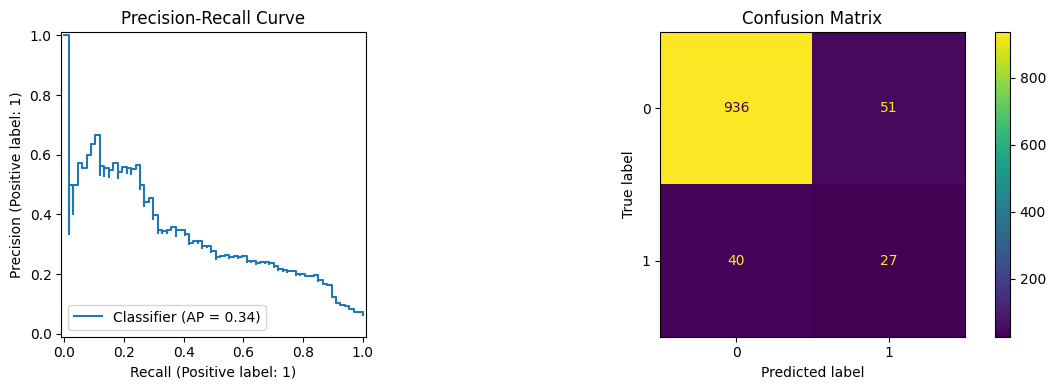

,accuracy,precision,recall,f1
modelname,,,,
Random Forest,0.9137,0.3462,0.4030,0.3724
Logistic,0.7884,0.2023,0.7910,0.3222


In [37]:
import pandas as pd

# Tạo lại bảng sạch (chỉ còn các cột cần thiết, không có roc_auc)
model_metrics = pd.DataFrame(columns=["modelname", "accuracy", "precision", "recall", "f1"])

# Áp dụng SMOTE
X_res, y_res = SMOTE(random_state=42).fit_resample(X_train_scaled, y_train)

# Logistic Regression
log = LogisticRegression(max_iter=1000, random_state=42)
log.fit(X_res, y_res)
metrics_log = evaluate_clf(log, "Logistic", X_test_scaled, y_test)
model_metrics = pd.concat([model_metrics, pd.DataFrame([metrics_log])], ignore_index=True)

# Random Forest
rf = RandomForestClassifier(n_estimators=800, random_state=42, n_jobs=-1)
rf.fit(X_res, y_res)
metrics_rf = evaluate_clf(rf, "Random Forest", X_test_scaled, y_test)
model_metrics = pd.concat([model_metrics, pd.DataFrame([metrics_rf])], ignore_index=True)

# Chuẩn bị hiển thị bảng
model_metrics = model_metrics.set_index('modelname')

# Sắp xếp theo f1 (hoặc bạn có thể chọn accuracy/recall tùy ý, vì không còn roc_auc)
# Ở đây mình chọn sort theo f1 descending - thường là metric quan trọng nhất trong bài toán imbalance
display(model_metrics.sort_values('f1', ascending=False)
        .style.background_gradient(cmap='Greens', subset=['f1'])  # Tô màu cột f1
        .highlight_max(axis=0, props='font-weight:bold; color:gold;')  # Highlight giá trị max từng cột
        .set_caption("SO SÁNH 2 MÔ HÌNH SAU SMOTE")
        .format("{:.4f}"))

In [38]:
import joblib
import pandas as pd
import numpy as np

joblib.dump(rf, 'model_tieuduong_best.pkl')
joblib.dump(scaler, 'scaler.pkl') 
joblib.dump(X_train_scaled.columns, 'columns.pkl')

def du_doan_tieu_duong(
    age, gender, pulse_rate, systolic_bp, diastolic_bp,
    glucose, height, weight, bmi,
    family_diabetes, hypertensive, family_hypertension,
    cardiovascular_disease, stroke
):
    model = joblib.load('model_tieuduong_best.pkl')
    scaler = joblib.load('scaler.pkl')
    cols = joblib.load('columns.pkl')
    
    # Tạo dữ liệu 1 người
    data = pd.DataFrame([[
        age, gender, pulse_rate, systolic_bp, diastolic_bp,
        glucose, height, weight, bmi,
        family_diabetes, hypertensive, family_hypertension,
        cardiovascular_disease, stroke
    ]], columns=cols)
    
    data_scaled = data.copy()
    data_scaled[cols_to_scale] = scaler.transform(data[cols_to_scale])
    
    # Dự đoán
    prob = model.predict_proba(data_scaled)[0][1]
    pred = "CÓ NGUY CƠ TIỂU ĐƯỜNG" if prob >= 0.5 else "BÌNH THƯỜNG"
    
    print(f"XÁC SUẤT BỊ TIỂU ĐƯỜNG: {prob:.1%}")
    print(f"KẾT LUẬN: {pred}")
    if prob >= 0.7:
        print("CẢNH BÁO MỨC ĐỎ - Khuyên đi khám ngay!")
    elif prob >= 0.5:
        print("CẢNH BÁO MỨC VÀNG - Cần theo dõi sát")
        
du_doan_tieu_duong(
    age=42, gender=1, pulse_rate=66, systolic_bp=110, diastolic_bp=73,
    glucose=5.88, height=1.63, weight=72.2, bmi=25.75,
    family_diabetes=0, hypertensive=1, family_hypertension=0,
    cardiovascular_disease=0, stroke=0
)

XÁC SUẤT BỊ TIỂU ĐƯỜNG: 15.1%
KẾT LUẬN: BÌNH THƯỜNG
